In [1]:
import pandas as pd
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

os.listdir(path)

c:\Users\Zi Hao\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Zi Hao\.cache\kagglehub\datasets\suchintikasarkar\sentiment-analysis-for-mental-health\versions\1


['Combined Data.csv']

In [2]:
import os

path_to_csv = os.path.join(path, "Combined Data.csv")

df = pd.read_csv(path_to_csv)

df = df.dropna()

In [3]:
df = df[df['status'].isin(['Normal', 'Depression', 'Anxiety', 'Suicidal', 'Stress'])]

Restructure label into severity level.

In [4]:
df = df[df['status'].isin(['Normal', 'Depression', 'Anxiety', 'Suicidal', 'Stress'])]

# Convert status into severity levels
severity_mapping = {
    'Normal': 0,
    'Stress': 1,
    'Anxiety': 1,
    'Depression': 2,
    'Suicidal': 3
}

df['severity'] = df['status'].map(severity_mapping)

In [5]:
df.drop(columns=['status'], inplace=True)

In [6]:
# Rename statement to text
df.rename(columns={'statement': 'text'}, inplace=True)

In [8]:
df.head()

,Unnamed: 0,statement,severity
0,0,oh my gosh,1
1,1,"trouble sleeping, confused mind, restless hear...",1
2,2,"All wrong, back off dear, forward doubt. Stay ...",1
3,3,I've shifted my focus to something else but I'...,1
4,4,"I'm restless and restless, it's been a month n...",1


In [45]:
df['word_len'] = df['text'].str.split().str.len()

df['word_len'].describe()

count    48827.000000
mean       108.113359
std        160.378628
min          1.000000
25%         14.000000
50%         56.000000
75%        140.000000
max       6300.000000
Name: word_len, dtype: float64

In [46]:
df.groupby('severity')['word_len'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
severity,,,,
0,17.246283,10.0,22.769056,16343
1,132.064406,93.0,136.513582,6428
2,168.021488,113.0,188.233087,15404
3,146.440293,92.0,186.963082,10652


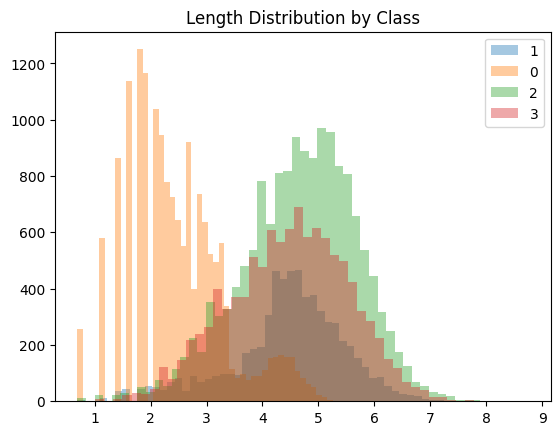

In [47]:
for label in df['severity'].unique():
    subset = df[df['severity'] == label]
    plt.hist(np.log1p(subset['word_len']), bins=50, alpha=0.4, label=label)

plt.legend()
plt.title('Length Distribution by Class')
plt.show()

## Preprocess Dataset

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)              # normalize whitespace
    text = re.sub(r'http\S+', '', text)           # remove URLs
    text = re.sub(r'[^\w\s.,!?]', '', text)       # keep emotional punctuation
    return text.strip()

df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['severity'],
    test_size=0.2,
    stratify=df['severity'],
    random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

models = {
    "logreg": LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    "svm": LinearSVC(class_weight='balanced'),
    "lgbm": LGBMClassifier(
        class_weight='balanced',
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )
}

### Evaluation

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']


results = {}

for name, model in models.items():
    pipeline = make_pipeline(tfidf, model)
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    results[name] = scores

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.517426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 643379
[LightGBM] [Info] Number of data points in the train set: 31248, number of used features: 9996
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


c:\Users\Zi Hao\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.554000 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 642519
[LightGBM] [Info] Number of data points in the train set: 31249, number of used features: 9997
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


c:\Users\Zi Hao\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.529957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 644619
[LightGBM] [Info] Number of data points in the train set: 31249, number of used features: 9995
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


c:\Users\Zi Hao\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.529059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 641235
[LightGBM] [Info] Number of data points in the train set: 31249, number of used features: 9995
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


c:\Users\Zi Hao\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.513486 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 640744
[LightGBM] [Info] Number of data points in the train set: 31249, number of used features: 9996
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


c:\Users\Zi Hao\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
# Extract and display results
for name, scores in results.items():
    print(f"Model: {name}")
    for metric in scoring:
        mean_score = scores[f'test_{metric}'].mean()
        std_score = scores[f'test_{metric}'].std()
        print(f"  {metric}: {mean_score:.4f} ± {std_score:.4f}")
    print()

Model: logreg
  accuracy: 0.8004 ± 0.0040
  f1_macro: 0.7931 ± 0.0051
  precision_macro: 0.7870 ± 0.0048
  recall_macro: 0.8051 ± 0.0060

Model: svm
  accuracy: 0.7924 ± 0.0051
  f1_macro: 0.7838 ± 0.0054
  precision_macro: 0.7815 ± 0.0046
  recall_macro: 0.7872 ± 0.0064

Model: lgbm
  accuracy: 0.8162 ± 0.0060
  f1_macro: 0.8110 ± 0.0068
  precision_macro: 0.8060 ± 0.0066
  recall_macro: 0.8180 ± 0.0072



### Experiment with DistilBERT

In [16]:
def smart_truncate(text, max_len=256):
    words = text.split()
    if len(words) <= max_len:
        return text
    
    half = max_len // 2
    return ' '.join(words[:half] + words[-half:])

df['truncated_text'] = df['clean_text'].apply(lambda x: smart_truncate(x, max_len=256))



In [25]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[['truncated_text', 'severity']],
    test_size=0.2,
    stratify=df['severity'],
    random_state=42
)

# Add this — rename columns before converting to Dataset
train_df = train_df.rename(columns={"severity": "labels"})
test_df = test_df.rename(columns={"severity": "labels"})

In [26]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

In [27]:
from transformers import AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch['truncated_text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map: 100%|██████████| 9766/9766 [00:01<00:00, 7921.34 examples/s]


In [28]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels= len(df['severity'].unique())
)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3523.56it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [29]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from transformers import DataCollatorWithPadding, Trainer

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average='macro'),
        "recall": recall_score(labels, preds, average='macro'),
        "precision": precision_score(labels, preds, average='macro')
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,  # replaces tokenizer
    compute_metrics=compute_metrics
)

In [30]:
print(train_dataset.column_names)   # should show: ['input_ids', 'attention_mask', 'labels']
print(train_dataset[0])             # labels value should be an int (e.g. 0 or 1)

['truncated_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']
{'labels': tensor(0), 'input_ids': tensor([ 101, 2123, 2102, 2412, 2022, 1999, 1037, 9241, 2043, 2115, 2063, 4439,
        1012,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
       

In [31]:
trainer.train()

c:\Users\Zi Hao\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
trainer.evaluate()